In [1]:
import numpy as np
import matplotlib.pyplot as plt
import glob
import os
import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [2]:
time = ['1 days', '2 days', '4 days', '7 days', '11 days', '17 days',
              '25 days', '37 days', '53 days', '77 days', '111 days', '158 days',
              '226 days', '323 days', '1.3 years', '1.8 years', '2.6 years',
              '3.6 years', '5.2 years', '7.3 years', '10.4 years', '14.8 years',
              '21.1 years', '30.0 years']

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Fixed dataset class for simple U-Net baseline from Iain code.

## Removing the 24-time-step output so can feed into U-Net baseline.

In [4]:
class ReservoirDatasetUNet(Dataset):
    def __init__(self, root_dir, target_nz=96, target_nx=200, time_index=-1):
        self.root_dir = root_dir
        self.target_nz = target_nz
        self.target_nx = target_nx
        self.time_index = time_index

        self.files = sorted(glob.glob(os.path.join(root_dir, "data_*.npz")))

    def __len__(self):
        return len(self.files)

    def resize_2d(self, arr):
        """
        Resize array from (nz, nx) to (target_nz, target_nx).
        """
        x = torch.tensor(arr, dtype=torch.float32)
        x = x.unsqueeze(0).unsqueeze(0)  # (1, 1, nz, nx)

        x = F.interpolate(
            x,
            size=(self.target_nz, self.target_nx),
            mode="bilinear",
            align_corners=False
        )

        return x.squeeze(0).squeeze(0)  # (target_nz, target_nx)

    def scalar_to_map(self, value):
        """
        Convert scalar value into constant 2D map.
        """
        value = float(np.asarray(value).reshape(-1)[0])
        return torch.full(
            (self.target_nz, self.target_nx),
            value,
            dtype=torch.float32
        )

    def __getitem__(self, index):
        file_path = self.files[index]

        with np.load(file_path) as data:
            # Spatial input variables
            porosity = self.resize_2d(data["porosity"])

            # Use log permeability because permeability usually has large dynamic range
            perm_r = self.resize_2d(data["perm_r"])
            perm_z = self.resize_2d(data["perm_z"])

            perm_r = torch.log10(torch.clamp(perm_r, min=1e-12))
            perm_z = torch.log10(torch.clamp(perm_z, min=1e-12))

            # Scalar input variables converted to maps
            inj_rate = self.scalar_to_map(data["inj_rate"])
            temperature = self.scalar_to_map(data["temperature"])
            depth = self.scalar_to_map(data["depth"])
            Swi = self.scalar_to_map(data["Swi"])
            lam = self.scalar_to_map(data["lam"])

            perf_interval = np.asarray(data["perf_interval"]).reshape(-1)
            perf_top = self.scalar_to_map(perf_interval[0])
            perf_bottom = self.scalar_to_map(perf_interval[1])

            # Stack input channels: (10, 96, 200)
            X = torch.stack([
                porosity,
                perm_r,
                perm_z,
                inj_rate,
                temperature,
                depth,
                Swi,
                lam,
                perf_top,
                perf_bottom
            ], dim=0)

            # Final-time output only for simple U-Net baseline
            pressure_final = self.resize_2d(data["pressure_buildup"][:, :, self.time_index])
            gas_final = self.resize_2d(data["gas_saturation"][:, :, self.time_index])

            # Stack target channels: (2, 96, 200)
            y = torch.stack([
                pressure_final,
                gas_final
            ], dim=0)

        return X, y

#Create dataset and test one sample

In [5]:
DATA_DIR = "/content/drive/MyDrive/train_data_set"

dataset = ReservoirDatasetUNet(DATA_DIR, target_nz=96, target_nx=200, time_index=-1)

print("Number of samples:", len(dataset))

X, y = dataset[0]

print("Input shape:", X.shape)
print("Output shape:", y.shape)
print("Input dtype:", X.dtype)
print("Output dtype:", y.dtype)

Number of samples: 4500
Input shape: torch.Size([10, 96, 200])
Output shape: torch.Size([2, 96, 200])
Input dtype: torch.float32
Output dtype: torch.float32


# Create DataLoader, good for U-Net baseline now. Removed the 24-time-step for training for now, no time-series.

In [7]:
loader = DataLoader(
    dataset,
    batch_size=8,
    shuffle=True,
    num_workers=0
)

X_batch, y_batch = next(iter(loader))

print("Batch input shape:", X_batch.shape)
print("Batch output shape:", y_batch.shape)

Batch input shape: torch.Size([8, 10, 96, 200])
Batch output shape: torch.Size([8, 2, 96, 200])


# Training U-Net baseline now. Train/validation split, compute normalisation statistics, wrap dataset with normalisation, Simple U-Net baseline model, test the model before training and training loop.

In [8]:
from torch.utils.data import random_split, DataLoader

train_ratio = 0.8

full_dataset = dataset   # important: use the full 4500-sample dataset

n_total = len(full_dataset)
n_train = int(train_ratio * n_total)
n_val = n_total - n_train

train_ds, val_ds = random_split(
    full_dataset,
    [n_train, n_val],
    generator=torch.Generator().manual_seed(42)
)

print("Total samples:", n_total)
print("Training samples:", len(train_ds))
print("Validation samples:", len(val_ds))

Total samples: 4500
Training samples: 3600
Validation samples: 900


In [9]:
from tqdm.auto import tqdm
from torch.utils.data import DataLoader, Dataset

def build_cache(ds, batch_size=16, num_workers=2):
    loader = DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        persistent_workers=True if num_workers > 0 else False
    )

    X_list = []
    y_list = []

    for X, y in tqdm(loader):
        X_list.append(X.cpu())
        y_list.append(y.cpu())

    X_all = torch.cat(X_list, dim=0)
    y_all = torch.cat(y_list, dim=0)

    return X_all, y_all

In [10]:
X_train, y_train = build_cache(train_ds, batch_size=16, num_workers=2)
X_val, y_val = build_cache(val_ds, batch_size=16, num_workers=2)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

  0%|          | 0/225 [00:00<?, ?it/s]

  0%|          | 0/57 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7ef3c2390ae0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
   Exception ignored in:  <function _MultiProcessingDataLoaderIter.__del__ at 0x7ef3c2390ae0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
      self._shutdown_workers()
   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
      if w.is_alive():
     ^  ^ ^ ^^^^^^^^^^^^^^^^^^^^^^

X_train: torch.Size([3600, 10, 96, 200])
y_train: torch.Size([3600, 2, 96, 200])
X_val: torch.Size([900, 10, 96, 200])
y_val: torch.Size([900, 2, 96, 200])


In [11]:
x_mean = X_train.mean(dim=(0, 2, 3))
x_std = X_train.std(dim=(0, 2, 3)).clamp_min(1e-6)

y_mean = y_train.mean(dim=(0, 2, 3))
y_std = y_train.std(dim=(0, 2, 3)).clamp_min(1e-6)

print("X mean:", x_mean)
print("X std:", x_std)
print("y mean:", y_mean)
print("y std:", y_std)

X mean: tensor([1.6991e-01, 1.7962e+00, 6.4340e-02, 1.1024e+00, 8.4042e+01, 2.0048e+02,
        2.0049e-01, 5.1335e-01, 1.1033e+01, 3.8228e+01])
X std: tensor([3.7127e-02, 9.2108e-01, 9.9843e-01, 5.2189e-01, 2.9680e+01, 5.8418e+01,
        5.7618e-02, 1.1347e-01, 1.3293e+01, 2.2961e+01])
y mean: tensor([22.6050,  0.1767])
y std: tensor([46.1369,  0.2905])


In [12]:
class NormalizedTensorDataset(Dataset):
    def __init__(self, X, y, x_mean, x_std, y_mean, y_std):
        self.X = X
        self.y = y

        self.x_mean = x_mean.view(1, -1, 1, 1)
        self.x_std = x_std.view(1, -1, 1, 1)

        self.y_mean = y_mean.view(1, -1, 1, 1)
        self.y_std = y_std.view(1, -1, 1, 1)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, index):
        X = (self.X[index] - self.x_mean.squeeze(0)) / self.x_std.squeeze(0)
        y = (self.y[index] - self.y_mean.squeeze(0)) / self.y_std.squeeze(0)

        return X.float(), y.float()

In [13]:
train_ds_norm = NormalizedTensorDataset(X_train, y_train, x_mean, x_std, y_mean, y_std)
val_ds_norm = NormalizedTensorDataset(X_val, y_val, x_mean, x_std, y_mean, y_std)

train_loader = DataLoader(
    train_ds_norm,
    batch_size=8,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_ds_norm,
    batch_size=8,
    shuffle=False,
    num_workers=0
)

X_batch, y_batch = next(iter(train_loader))

print("Batch input shape:", X_batch.shape)
print("Batch output shape:", y_batch.shape)

Batch input shape: torch.Size([8, 10, 96, 200])
Batch output shape: torch.Size([8, 2, 96, 200])


In [14]:
import torch.nn as nn
import torch.nn.functional as F

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.SiLU(),

            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.SiLU()
        )

    def forward(self, x):
        return self.block(x)


class UNetBaseline(nn.Module):
    def __init__(self, in_channels=10, out_channels=2, base_channels=32):
        super().__init__()

        self.enc1 = DoubleConv(in_channels, base_channels)
        self.enc2 = DoubleConv(base_channels, base_channels * 2)
        self.enc3 = DoubleConv(base_channels * 2, base_channels * 4)

        self.pool = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(base_channels * 4, base_channels * 8)

        self.dec3 = DoubleConv(base_channels * 8 + base_channels * 4, base_channels * 4)
        self.dec2 = DoubleConv(base_channels * 4 + base_channels * 2, base_channels * 2)
        self.dec1 = DoubleConv(base_channels * 2 + base_channels, base_channels)

        self.final = nn.Conv2d(base_channels, out_channels, kernel_size=1)

    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)              # (B, 32, 96, 200)
        e2 = self.enc2(self.pool(e1))  # (B, 64, 48, 100)
        e3 = self.enc3(self.pool(e2))  # (B, 128, 24, 50)

        b = self.bottleneck(self.pool(e3))

        # Decoder
        d3 = F.interpolate(b, size=e3.shape[2:], mode="bilinear", align_corners=False)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = F.interpolate(d3, size=e2.shape[2:], mode="bilinear", align_corners=False)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = F.interpolate(d2, size=e1.shape[2:], mode="bilinear", align_corners=False)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return self.final(d1)

In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# rerun everytime to resets the model weights
model = UNetBaseline(in_channels=10, out_channels=2, base_channels=32).to(device)

X_batch, y_batch = next(iter(train_loader))
X_batch = X_batch.to(device)
y_batch = y_batch.to(device)

with torch.no_grad():
    pred = model(X_batch)

print("Input batch shape:", X_batch.shape, X_batch.dtype)
print("Prediction shape:", pred.shape)
print("Target batch shape:", y_batch.shape, y_batch.dtype)
print("X finite:", torch.isfinite(X_batch).all().item())
print("y finite:", torch.isfinite(y_batch).all().item())
print("X mean after norm:", X_batch.mean().item())
print("X std after norm:", X_batch.std().item())
print("y mean after norm:", y_batch.mean().item())
print("y std after norm:", y_batch.std().item())

Using device: cuda
Input batch shape: torch.Size([8, 10, 96, 200]) torch.float32
Prediction shape: torch.Size([8, 2, 96, 200])
Target batch shape: torch.Size([8, 2, 96, 200]) torch.float32
X finite: True
y finite: True
X mean after norm: -0.05161534994840622
X std after norm: 0.8954871296882629
y mean after norm: -0.05552072077989578
y std after norm: 0.8587514758110046


In [16]:
criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-6
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=10
)

num_epochs = 200
early_stop_patience = 25

train_losses = []
val_losses = []

best_val_loss = float("inf")
best_epoch = 0
epochs_without_improvement = 0

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0

    for X, y in train_loader:
        X = X.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        pred = model(X)
        loss = criterion(pred, y)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * X.size(0)

    train_loss /= len(train_loader.dataset)

    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for X, y in val_loader:
            X = X.to(device)
            y = y.to(device)

            pred = model(X)
            loss = criterion(pred, y)

            val_loss += loss.item() * X.size(0)

    val_loss /= len(val_loader.dataset)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    scheduler.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch + 1
        epochs_without_improvement = 0
        checkpoint_path = "/content/drive/MyDrive/best_unet_baseline_full.pt"

        torch.save({
            "model_state_dict": model.state_dict(),
            "x_mean": x_mean.cpu(),
            "x_std": x_std.cpu(),
            "y_mean": y_mean.cpu(),
            "y_std": y_std.cpu(),
            "train_losses": train_losses,
            "val_losses": val_losses,
            "best_val_loss": best_val_loss,
            "best_epoch": best_epoch,
            "train_indices": train_ds.indices,
            "val_indices": val_ds.indices,
        }, checkpoint_path)

    else:
        epochs_without_improvement += 1

    current_lr = optimizer.param_groups[0]["lr"]

    print(
        f"Epoch [{epoch+1}/{num_epochs}] | "
        f"Train Loss: {train_loss:.6f} | "
        f"Val Loss: {val_loss:.6f} | "
        f"Best Val: {best_val_loss:.6f} at epoch {best_epoch} | "
        f"LR: {current_lr:.2e}"
    )

    if epochs_without_improvement >= early_stop_patience:
        print(f"Early stopping at epoch {epoch+1}")
        break

Epoch [1/200] | Train Loss: 0.510410 | Val Loss: 0.406533 | Best Val: 0.406533 at epoch 1 | LR: 1.00e-03
Epoch [2/200] | Train Loss: 0.373841 | Val Loss: 0.310749 | Best Val: 0.310749 at epoch 2 | LR: 1.00e-03
Epoch [3/200] | Train Loss: 0.344655 | Val Loss: 0.285491 | Best Val: 0.285491 at epoch 3 | LR: 1.00e-03
Epoch [4/200] | Train Loss: 0.329720 | Val Loss: 0.260017 | Best Val: 0.260017 at epoch 4 | LR: 1.00e-03
Epoch [5/200] | Train Loss: 0.320496 | Val Loss: 0.257280 | Best Val: 0.257280 at epoch 5 | LR: 1.00e-03
Epoch [6/200] | Train Loss: 0.315887 | Val Loss: 0.253425 | Best Val: 0.253425 at epoch 6 | LR: 1.00e-03
Epoch [7/200] | Train Loss: 0.306007 | Val Loss: 0.279858 | Best Val: 0.253425 at epoch 6 | LR: 1.00e-03
Epoch [8/200] | Train Loss: 0.298157 | Val Loss: 0.245874 | Best Val: 0.245874 at epoch 8 | LR: 1.00e-03
Epoch [9/200] | Train Loss: 0.284620 | Val Loss: 0.303486 | Best Val: 0.245874 at epoch 8 | LR: 1.00e-03
Epoch [10/200] | Train Loss: 0.276586 | Val Loss: 0.262

In [17]:
checkpoint = torch.load("/content/drive/MyDrive/best_unet_baseline_full.pt", map_location=device)

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

x_mean = checkpoint["x_mean"]
x_std = checkpoint["x_std"]
y_mean = checkpoint["y_mean"]
y_std = checkpoint["y_std"]

print("Loaded best model from epoch:", checkpoint["best_epoch"])
print("Best validation loss:", checkpoint["best_val_loss"])

Loaded best model from epoch: 102
Best validation loss: 0.1800121342142423


# Plot the loss curve

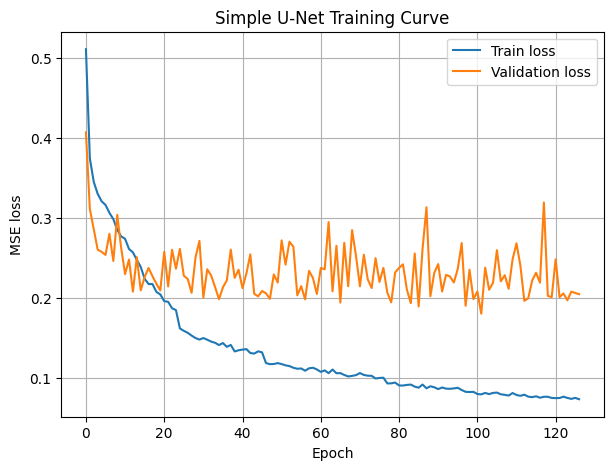

In [18]:
# Plot until 127 epochs where early stopping is
plt.figure(figsize=(7,5))
plt.plot(train_losses, label="Train loss")
plt.plot(val_losses, label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Simple U-Net Training Curve")
plt.legend()
plt.grid(True)
plt.show()

# Visualize prediction quality

In [26]:
model.eval()

pressure_true_all = []
pressure_pred_all = []
sat_true_all = []
sat_pred_all = []

y_mean_cpu = y_mean.cpu()
y_std_cpu = y_std.cpu()

y_mean_view = y_mean_cpu.view(1, 2, 1, 1)
y_std_view = y_std_cpu.view(1, 2, 1, 1)

with torch.no_grad():
    for X, y in val_loader:
        X = X.to(device)
        y = y.to(device)

        pred_norm = model(X)

        pred_norm = pred_norm.cpu()
        y = y.cpu()

        pred = pred_norm * y_std_view + y_mean_view
        true = y * y_std_view + y_mean_view

        # Optional physical clamp for saturation evaluation
        pred[:, 1] = torch.clamp(pred[:, 1], 0, 1)

        pressure_true_all.append(true[:, 0].reshape(-1))
        pressure_pred_all.append(pred[:, 0].reshape(-1))

        sat_true_all.append(true[:, 1].reshape(-1))
        sat_pred_all.append(pred[:, 1].reshape(-1))

pressure_true_all = torch.cat(pressure_true_all)
pressure_pred_all = torch.cat(pressure_pred_all)

sat_true_all = torch.cat(sat_true_all)
sat_pred_all = torch.cat(sat_pred_all)

def rmse(pred, true):
    return torch.sqrt(torch.mean((pred - true) ** 2)).item()

def mae(pred, true):
    return torch.mean(torch.abs(pred - true)).item()

def r2_score(pred, true):
    ss_res = torch.sum((true - pred) ** 2)
    ss_tot = torch.sum((true - torch.mean(true)) ** 2)
    return (1 - ss_res / ss_tot).item()

print("Pressure metrics")
print("RMSE:", rmse(pressure_pred_all, pressure_true_all))
print("MAE: ", mae(pressure_pred_all, pressure_true_all))
print("R2:  ", r2_score(pressure_pred_all, pressure_true_all))

print("\nGas saturation metrics")
print("RMSE:", rmse(sat_pred_all, sat_true_all))
print("MAE: ", mae(sat_pred_all, sat_true_all))
print("R2:  ", r2_score(sat_pred_all, sat_true_all))

Pressure metrics
RMSE: 20.418718338012695
MAE:  8.524595260620117
R2:   0.8094509840011597

Gas saturation metrics
RMSE: 0.11735892295837402
MAE:  0.05790037661790848
R2:   0.8364036083221436


# Plot pressure and gas saturation for first four validation sample.

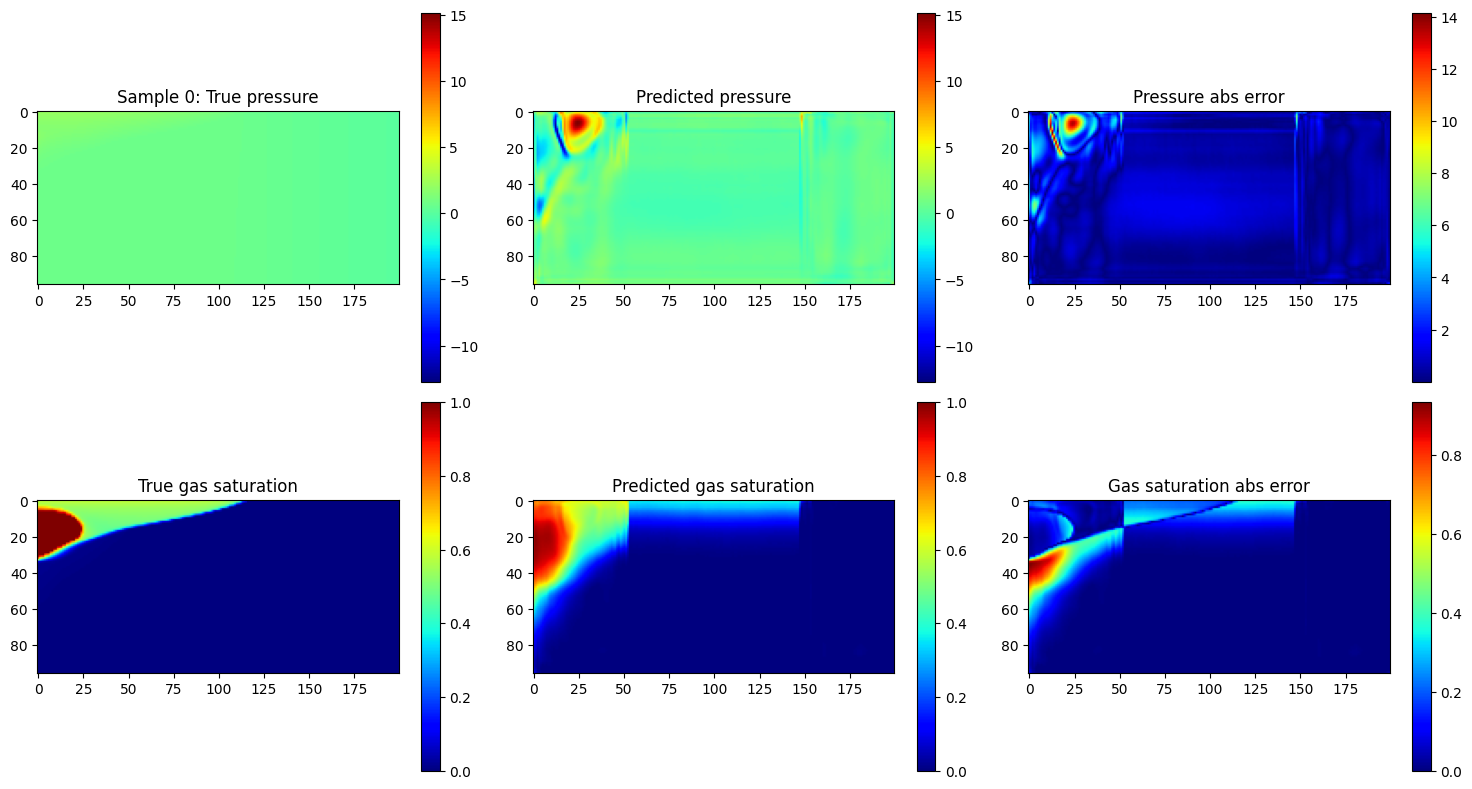

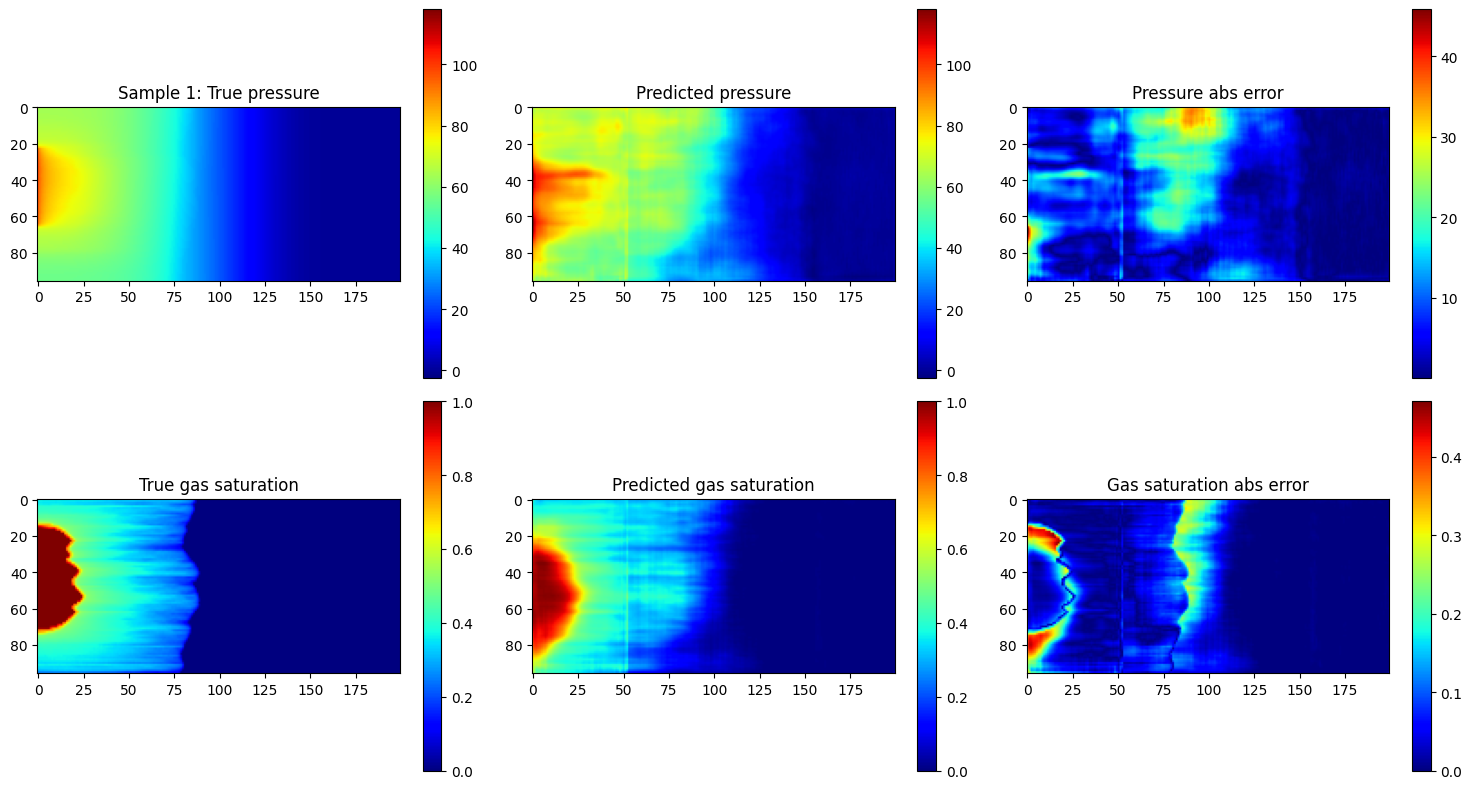

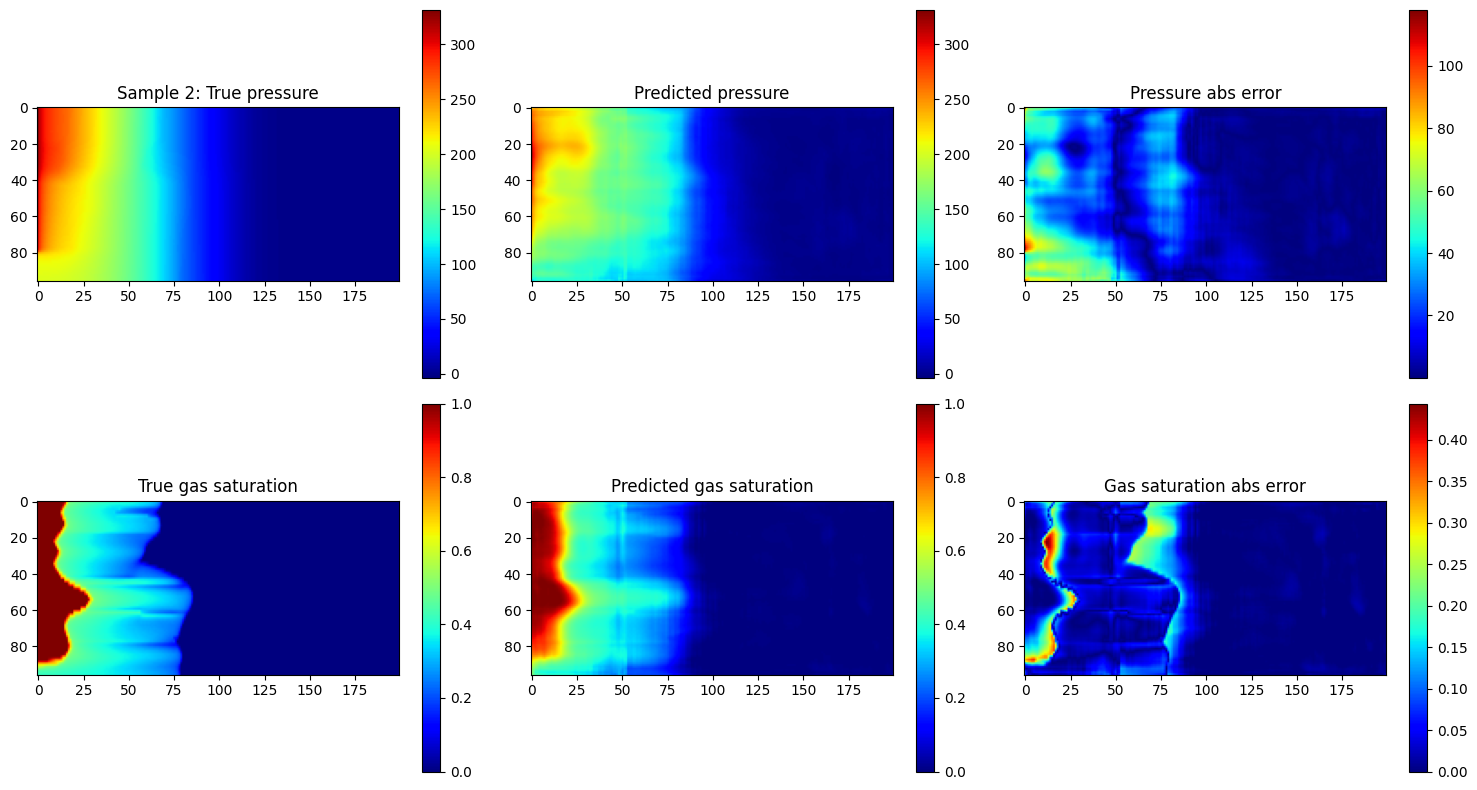

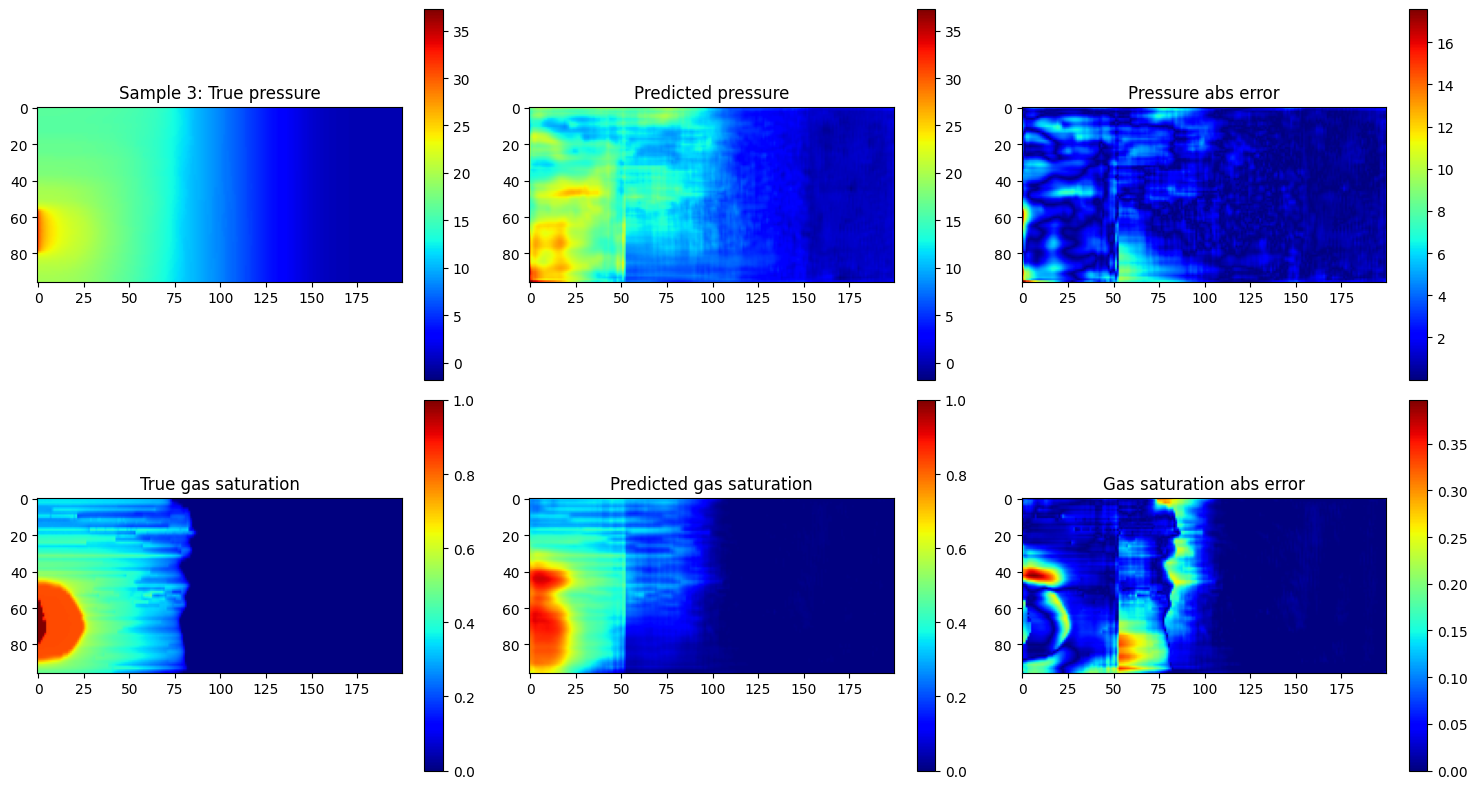

In [25]:
for sample_id in range(4):
    pressure_vmin = min(true[sample_id, 0].min(), pred[sample_id, 0].min())
    pressure_vmax = max(true[sample_id, 0].max(), pred[sample_id, 0].max())

    sat_vmin = 0
    sat_vmax = 1

    pred_plot = pred.clone()
    pred_plot[:, 1] = torch.clamp(pred_plot[:, 1], 0, 1)

    plt.figure(figsize=(15, 8))

    plt.subplot(2, 3, 1)
    plt.imshow(true[sample_id, 0], cmap="jet", vmin=pressure_vmin, vmax=pressure_vmax)
    plt.colorbar()
    plt.title(f"Sample {sample_id}: True pressure")

    plt.subplot(2, 3, 2)
    plt.imshow(pred_plot[sample_id, 0], cmap="jet", vmin=pressure_vmin, vmax=pressure_vmax)
    plt.colorbar()
    plt.title("Predicted pressure")

    plt.subplot(2, 3, 3)
    plt.imshow(torch.abs(true[sample_id, 0] - pred_plot[sample_id, 0]), cmap="jet")
    plt.colorbar()
    plt.title("Pressure abs error")

    plt.subplot(2, 3, 4)
    plt.imshow(true[sample_id, 1], cmap="jet", vmin=sat_vmin, vmax=sat_vmax)
    plt.colorbar()
    plt.title("True gas saturation")

    plt.subplot(2, 3, 5)
    plt.imshow(pred_plot[sample_id, 1], cmap="jet", vmin=sat_vmin, vmax=sat_vmax)
    plt.colorbar()
    plt.title("Predicted gas saturation")

    plt.subplot(2, 3, 6)
    plt.imshow(torch.abs(true[sample_id, 1] - pred_plot[sample_id, 1]), cmap="jet")
    plt.colorbar()
    plt.title("Gas saturation abs error")

    plt.tight_layout()
    plt.show()

# For pressure:
## the model captures the broad left-to-right pressure gradient in Samples 1-3. That is good. However, it often produces a more blurred or blocky pressure field than the true result. In Sample 0, the true pressure is almost uniform, but the model predicts a false local pressure anomaly near the upper-left. That means the model sometimes invents features.

# For gas saturation
## the model captures the main plume location near the injection side, which is good. But the predicted plume is generally smoother, more spread out, and less sharp than the true saturation front. It also tends to underrepresent the high-saturation red zone and overpredict intermediate saturation in places where the true plume front is sharper.

Good:
- Learns the general spatial pattern.
- Finds the main CO2 plume region.
- Pressure gradient is broadly correct.
- Saturation front position is roughly learned.

Not so good:
- Plume fronts are too smooth.
- High-saturation regions are underestimated.
- Some false positive structures appear.
- Validation loss is unstable and train/val gap is quite large.